In [27]:
# for datasets in sim 3- counts are generated so that the ratios are close the real data noise level 2 

In [1]:
import os
from pathlib import Path
import sys
import numpy as np
import scvelo as scv

In [2]:
notebook_dir = os.getcwd()
notebook_dir

'c:\\Users\\OmerCagatayTalikaci\\Desktop\\github\\STVelo\\notebooks\\analysis\\nuc_cyto_vs_spl_uns'

In [3]:
Path(notebook_dir).parents[3]

WindowsPath('c:/Users/OmerCagatayTalikaci/Desktop/github')

In [4]:
os.chdir(Path(notebook_dir).parents[3])

In [5]:
stvelo_path = os.path.join(os.getcwd(),'STVelo','stvelo')

import sys  
sys.path.insert(1,stvelo_path)

from pipelines.metrics import *
from pipelines.utils import proportions_nuc_cyto

# Read adatas 

In [6]:
adata_folder_path = os.path.join(os.getcwd(), 'data', 'sim3') 

In [7]:
import os
import anndata as ad


# Initialize an empty dictionary to store the AnnData objects
adata_dict = {}

# Loop through all files in the folder
for file_name in os.listdir(adata_folder_path):
    # Check if the file has .h5ad extension
    if file_name.endswith('.h5ad'):
        # Remove the file extension to use as the dictionary key
        key = os.path.splitext(file_name)[0]
        
        # Read the .h5ad file and store it in the dictionary
        adata_dict[key] = scv.read(os.path.join(adata_folder_path, file_name))

# Now, adata_dict contains the .h5ad files with keys as their filenames without extension


In [8]:
adatas = {k:v.copy() for k,v in adata_dict.items()}

In [9]:
# adata shuffled 
spliced_n_c = adatas['adata_n_c_800obs_300genes_deterministic'].layers['spliced']

for col in range(spliced_n_c.shape[1]):
    np.random.shuffle(spliced_n_c[:, col])


In [10]:
unspliced_n_c = adatas['adata_n_c_800obs_300genes_deterministic'].layers['unspliced']

for col in range(unspliced_n_c.shape[1]):
    np.random.shuffle(unspliced_n_c[:, col])

In [11]:
adata_random = adatas['adata_n_c_800obs_300genes_deterministic'].copy()

In [12]:
adata_random.layers['spliced'] = spliced_n_c
adata_random.layers['unspliced'] = unspliced_n_c

In [13]:
adata_random.X = spliced_n_c+unspliced_n_c

In [14]:
adata_dict['adata_n_c_800obs_300genes_deterministic'].layers['spliced']

array([[ 0.54347237,  0.        , 30.10202399, ...,  2.19024226,
         0.        ,  1.3497601 ],
       [ 1.05771543,  0.        ,  0.        , ...,  0.        ,
         0.        , 18.1776206 ],
       [38.06591839, 39.08597637, 19.27090606, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [33.27439391,  0.        ,  1.72774971, ...,  0.        ,
        12.29584181,  5.11522256],
       [33.42618834,  0.        ,  7.04426141, ...,  0.        ,
        16.46342683, 21.52983178],
       [ 4.96829391, 38.06263156,  0.        , ...,  0.        ,
        11.89153648,  0.        ]])

In [15]:
adata_dict['random'] = adata_random

In [16]:
adata_dict['adata_n_c_1000obs_300genes_deterministic'].var

,true_t_,true_alpha,true_beta,true_nu,true_gamma,true_scaling,n_cells,velocity_gamma,velocity_qreg_ratio,velocity_r2,velocity_genes
0,9.210945,121.071369,1.158334,1.550781,0.972234,1.0,951,1.447526,1.447526,0.621974,True
1,11.704723,345.072610,2.556930,2.068045,2.087270,1.0,959,1.786962,1.786962,0.783541,True
2,10.012711,85.396915,0.501976,1.095564,0.939370,1.0,982,2.865124,2.865124,0.375405,True
3,9.163710,178.920057,1.310834,1.620235,1.449987,1.0,960,1.947735,1.947735,0.722559,True
4,7.319093,55.901317,1.297507,2.030203,1.643886,1.0,956,2.067548,2.067548,0.817248,True
...,...,...,...,...,...,...,...,...,...,...,...
295,4.349492,562.270816,1.942090,0.836347,0.540731,1.0,949,1.225766,1.225766,0.069458,True
296,2.414075,153.657454,1.589935,1.515830,1.444210,1.0,915,2.197103,2.197103,0.492813,True
297,13.913932,83.818027,1.145523,0.948699,3.836376,1.0,991,7.249262,7.249262,0.635571,True
298,15.566869,66.330040,0.768410,0.487168,1.811969,1.0,998,6.022511,6.022511,0.726281,True


# n_obs = 800

In [12]:
adata_800 = {'adata_n_c_800obs_300genes_deterministic': adata_dict['adata_n_c_800obs_300genes_deterministic'].copy(),
             'adata_s_u_800obs_300genes_deterministic': adata_dict['adata_s_u_800obs_300genes_deterministic'].copy()}

In [13]:
adata_n_c_800obs = adata_dict['adata_n_c_800obs_300genes_deterministic'].copy()
adata_s_u_800obs = adata_dict['adata_s_u_800obs_300genes_deterministic'].copy()

In [14]:
import matplotlib.pyplot as plt 

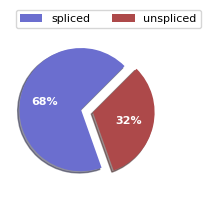

In [15]:
scv.pl.proportions(adata_800['adata_s_u_800obs_300genes_deterministic'])

<Axes: >

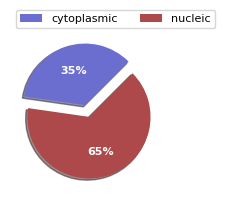

In [16]:
proportions_nuc_cyto(adata_800['adata_n_c_800obs_300genes_deterministic'])

# Metrics 

# Confidence 

- Confidence metric measures the mean velocity consistency by calculating the pearson correlation between a cell and its neighbours. Let $v(x_j)$ be the velocity of cell $x_j$. Confidence $c_j$ is given by;

$$c_j = \frac{1}{k} \sum_{x \in \mathit{N_k(x_j)} } corr(v(x_j),v(x))$$

where $\mathit{N_k(x_j)}$ is the k-neighbours of $x_j$ in KNN graph.


sc.pp.neighbors(adata) > scv.tl.velocity() > scv.tl.velocity_graph() to compute cosine corr. > scv.tl.velocity_confidence()

In [17]:
for d in adata_dict.keys():
    print(d)
    adata_dict[d]=compute_confidence(adata_dict[d])

adata_n_c_1000obs_300genes_deterministic
computing velocity graph (using 2/24 cores)
or disable the progress bar using `show_progress_bar=False`.
    finished (0:00:11) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
adata_n_c_800obs_300genes_deterministic
computing velocity graph (using 2/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
adata_s_u_1000obs_300genes_deterministic
computing velocity graph (using 2/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--

<Axes: xlabel='Velocity confidence', ylabel='velo_type'>

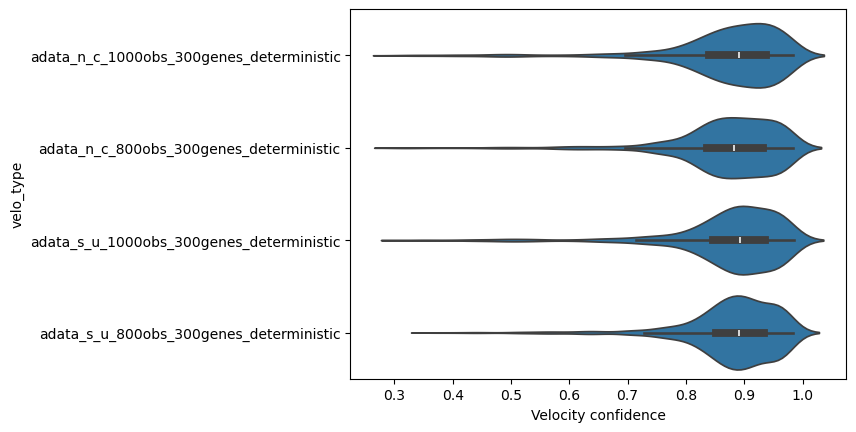

In [18]:
import seaborn as sns
confidences=get_confidences(adata_dict)
sns.violinplot(data=confidences,x='Velocity confidence',y='velo_type')

In [19]:
for d in adata_800.keys():
    print(d)
    adata_800[d]=compute_confidence(adata_800[d])

adata_n_c_800obs_300genes_deterministic
computing velocity graph (using 2/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)
adata_s_u_800obs_300genes_deterministic
computing velocity graph (using 2/24 cores)
    finished (0:00:01) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


<Axes: xlabel='Velocity confidence', ylabel='velo_type'>

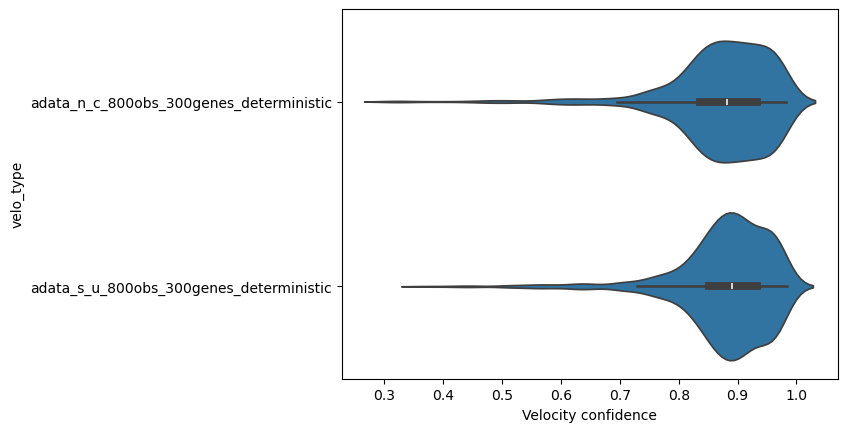

In [23]:
# confidence
import seaborn as sns
confidences=get_confidences(adata_800)
sns.violinplot(data=confidences,x='Velocity confidence',y='velo_type')

- velocities looks consistent for the neighbours in KNN for both of the model. Nuc - cyto model has better mean.

- similar performances between models was expected as the total sum is same. For further investigation we can check if there is a difference in leidens groups.  

- noise for these datas are bigger thatn the 01_analysis and it look like noise effects n_c model more for the local consistancy.

- more counts make the model more robost implies noise effects nuclein cyto more. 



In [20]:
import matplotlib.pyplot as plt

In [22]:
leiden_clusters = adata_800['adata_n_c_800obs_300genes_deterministic'].obs['leiden']

In [23]:
leiden_clusters = pd.concat([leiden_clusters,leiden_clusters])

In [24]:
leiden_clusters.reset_index(inplace=True, drop=True)

In [25]:
confidences.reset_index(inplace=True, drop=True)

In [26]:
confidences['leiden'] =leiden_clusters

<Axes: xlabel='cell_id', ylabel='Velocity confidence'>

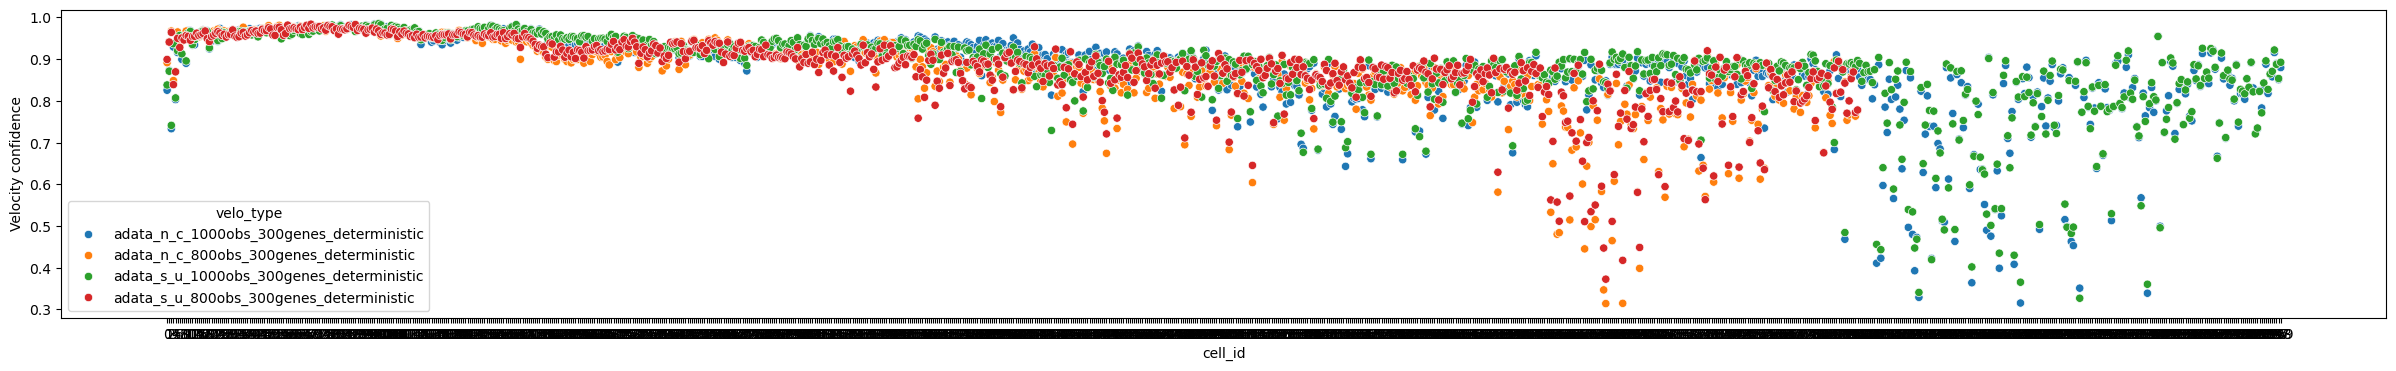

In [27]:
plt.figure(figsize=(30,4))
sns.scatterplot(data=confidences,x='cell_id',y= 'Velocity confidence', hue='velo_type')

<Axes: xlabel='cell_id', ylabel='Velocity confidence'>

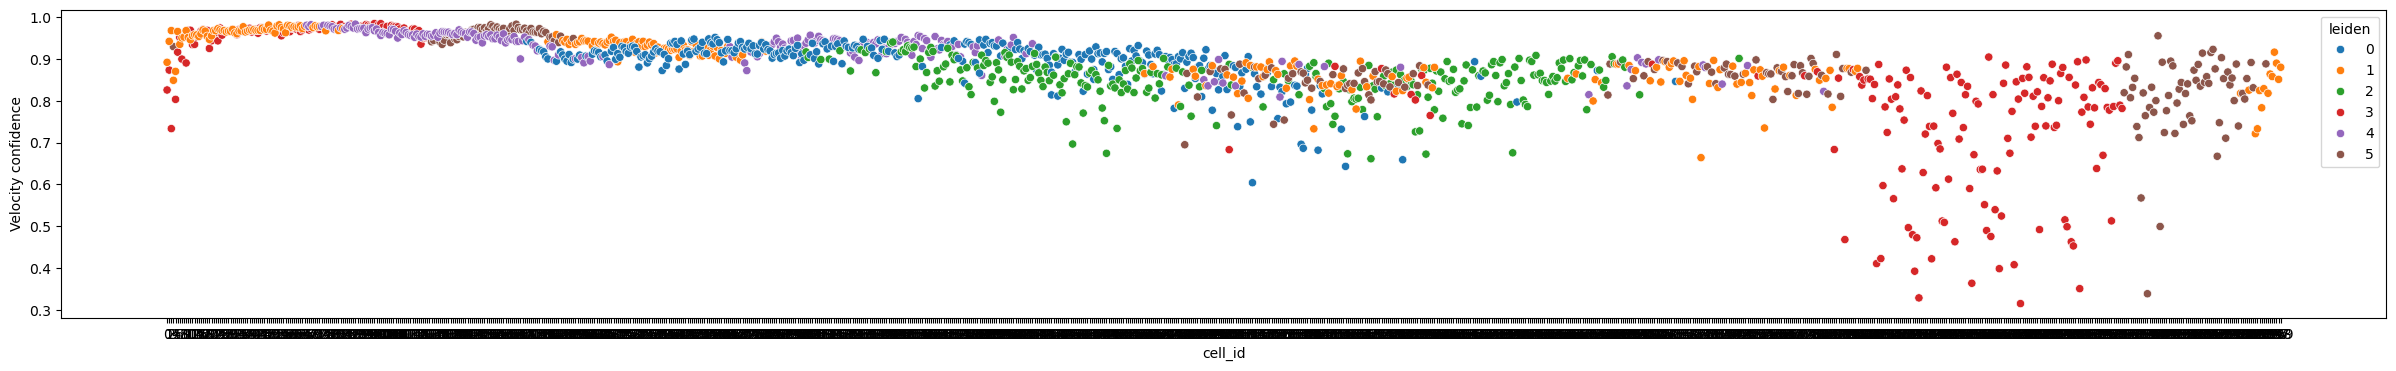

In [28]:
plt.figure(figsize=(30,4))
sns.scatterplot(data=confidences,x='cell_id',y= 'Velocity confidence', hue='leiden')

In [29]:
confidences.groupby(['velo_type','leiden'])['Velocity confidence'].mean()

velo_type                                 leiden
adata_n_c_1000obs_300genes_deterministic  0         0.874940
                                          1         0.893951
                                          2         0.838668
                                          3         0.836106
                                          4         0.923797
                                          5         0.879981
adata_n_c_800obs_300genes_deterministic   0         0.912005
                                          1         0.916554
                                          2         0.863179
                                          3         0.812403
                                          4         0.945061
                                          5         0.842747
adata_s_u_1000obs_300genes_deterministic  0              NaN
                                          1              NaN
                                          2              NaN
                                    

- it can be seen from the graphs above that the overall performance velocity consistency is looks same for most of the groups.
- for l-4 and l-5 velocity consistency is better for the spl - uns approach, wheras for l-0 nuc-cyt model gives better scores. Reason?
    - assumption 1. : differences in counts might effect the overal perf of specfic groups. velocity genes can be checked.
    - deterministic model assumes beta = 1. as total spliced counts > cyto counts, for groups which have cells near steady state, difference in the counts make dynamics more clear or vouge. Velocity lenghts might be checked. 

## Velocity length for different leiden clusters  

In [30]:
adata_800['adata_n_c_800obs_300genes_deterministic'].obs.groupby('leiden')['velocity_length'].mean()

leiden
0    628.929749
1    747.023499
2    534.510864
3    970.659973
4    808.890930
5    770.087097
Name: velocity_length, dtype: float32

In [31]:
adata_800['adata_s_u_800obs_300genes_deterministic'].obs.groupby('leiden')['velocity_length'].mean()

leiden
0    344.796265
1    406.687012
2    292.785217
3    518.073669
4    390.104675
5    428.994598
Name: velocity_length, dtype: float32

- velocity lengths are much bigger in nuc cyt model. However this shouldn't directly influence pearson correlation since the difference in vectors normalized by their norms.  

In [32]:
spl = adata_800['adata_s_u_800obs_300genes_deterministic'].layers['spliced'] 
uns = adata_800['adata_s_u_800obs_300genes_deterministic'].layers['unspliced']
nuc = adata_800['adata_n_c_800obs_300genes_deterministic'].layers['spliced']
cyt = adata_800['adata_n_c_800obs_300genes_deterministic'].layers['unspliced']

In [33]:
np.sum(uns,axis=0)/np.sum(spl,axis=0)

array([0.51658138, 0.40813696, 1.02937371, 0.60303526, 0.73561047,
       0.48447513, 1.14683557, 0.29648206, 1.10750546, 0.31412898,
       0.23766106, 0.47692395, 0.57357538, 0.95752187, 0.30840185,
       0.38963023, 1.10458263, 0.67226631, 0.22393426, 0.42294468,
       0.21448475, 0.31765966, 0.55510113, 0.50661154, 0.68213172,
       0.42221163, 0.36580838, 0.37512897, 0.07578907, 0.60919854,
       0.50808559, 0.35117975, 0.74946875, 0.3253723 , 0.35304988,
       0.70163234, 0.6955966 , 0.96303991, 0.79735633, 0.31299301,
       0.32166461, 0.24816699, 0.27175952, 0.47781607, 0.42708049,
       0.38224865, 1.55799775, 0.43579163, 0.99979606, 0.19745817,
       1.52460021, 1.4346901 , 0.64126556, 0.88188599, 0.39365505,
       0.22532487, 0.71523592, 0.87879559, 0.38430165, 0.71677447,
       1.01194502, 1.80906747, 0.41433197, 0.22972197, 0.27550547,
       2.12475576, 0.43964808, 0.88235068, 0.42649644, 0.62826265,
       1.17733604, 0.31602138, 0.70186042, 0.51367165, 0.19926

In [32]:
adata_800['adata_s_u_800obs_300genes_deterministic'].var.velocity_gamma

0      0.037515
1      0.310046
2      0.089633
3      0.371787
4      0.206863
         ...   
295    0.310316
296    0.419122
297    0.078657
298    0.115094
299    0.122477
Name: velocity_gamma, Length: 300, dtype: float32

For deterministic model $\beta = 1 $. velocity gamma is given by $\frac{n}{s}$ for cells which is the value for having the steady state, and velocity $\frac{ds}{dt} = u - \gamma s$ 

# Velocity Correlation by gene

Checks if the velocities calculated for the same gene in different modalities are consistent. 

In [34]:
velocity_correlation_by_gene=velocity_corr_against_reference(adata_800,reference='adata_s_u_800obs_300genes_deterministic', mode= 'by_gene')

Text(0, 0.5, 'Modality')

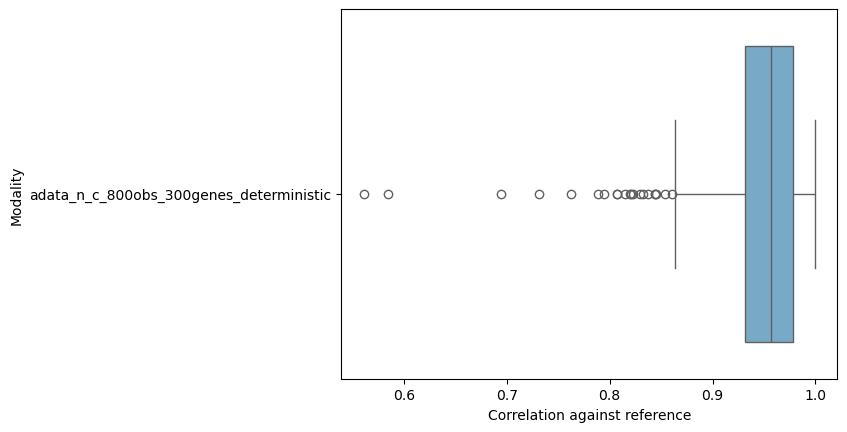

In [35]:
# velocity corr against a reference 
# import matplotlib.pyplot as plt
# sns.clustermap(velocity_correlation_by_gene.fillna(0),figsize=(7,4),cmap='Blues')
# sns.scatterplot(velocity_correlation_by_gene[:1].T)
# plt.figure(figsize=(5,5))
sns.boxplot(data=velocity_correlation_by_gene[:1].stack().reset_index(),y='level_0',x=0,palette='Blues')
plt.xlabel('Correlation against reference')
plt.ylabel('Modality')


- It looks like the model capture more or less the same dynamics for the genes in two modalities. Investigate lover correlations:

In [36]:
velo_genes_s_u = adata_800['adata_s_u_800obs_300genes_deterministic'].var['velocity_genes']
velo_genes_n_c = adata_800['adata_n_c_800obs_300genes_deterministic'].var['velocity_genes']

In [37]:
print(velo_genes_n_c.value_counts(),velo_genes_s_u.value_counts())

velocity_genes
True     271
False     29
Name: count, dtype: int64 velocity_genes
True     254
False     46
Name: count, dtype: int64


In [38]:
a = pd.DataFrame(velocity_correlation_by_gene.T)
a['velo_gene_s_u'] = velo_genes_s_u
a['velo_genes_u_n'] = velo_genes_n_c

In [39]:
a.iloc[0:,:4].sort_values('adata_n_c_800obs_300genes_deterministic').head(-5)


,adata_n_c_800obs_300genes_deterministic,adata_s_u_800obs_300genes_deterministic,velo_gene_s_u,velo_genes_u_n
14,0.561229,1.0,False,True
171,0.584271,1.0,False,True
198,0.694344,1.0,False,True
283,0.731220,1.0,True,True
241,0.762268,1.0,True,True
...,...,...,...,...
250,0.993863,1.0,True,True
125,0.993951,1.0,True,True
267,0.994474,1.0,True,True
197,0.996177,1.0,True,True


In [40]:
alpha = adata_s_u_800obs.var['true_alpha']
beta = adata_s_u_800obs.var['true_beta']
nu = adata_s_u_800obs.var['true_nu']
gamma = adata_s_u_800obs.var['true_nu']

In [58]:
((gamma*(beta+nu))/beta*nu)[171]

0.4019214905924193

In [56]:
160/225

0.7111111111111111

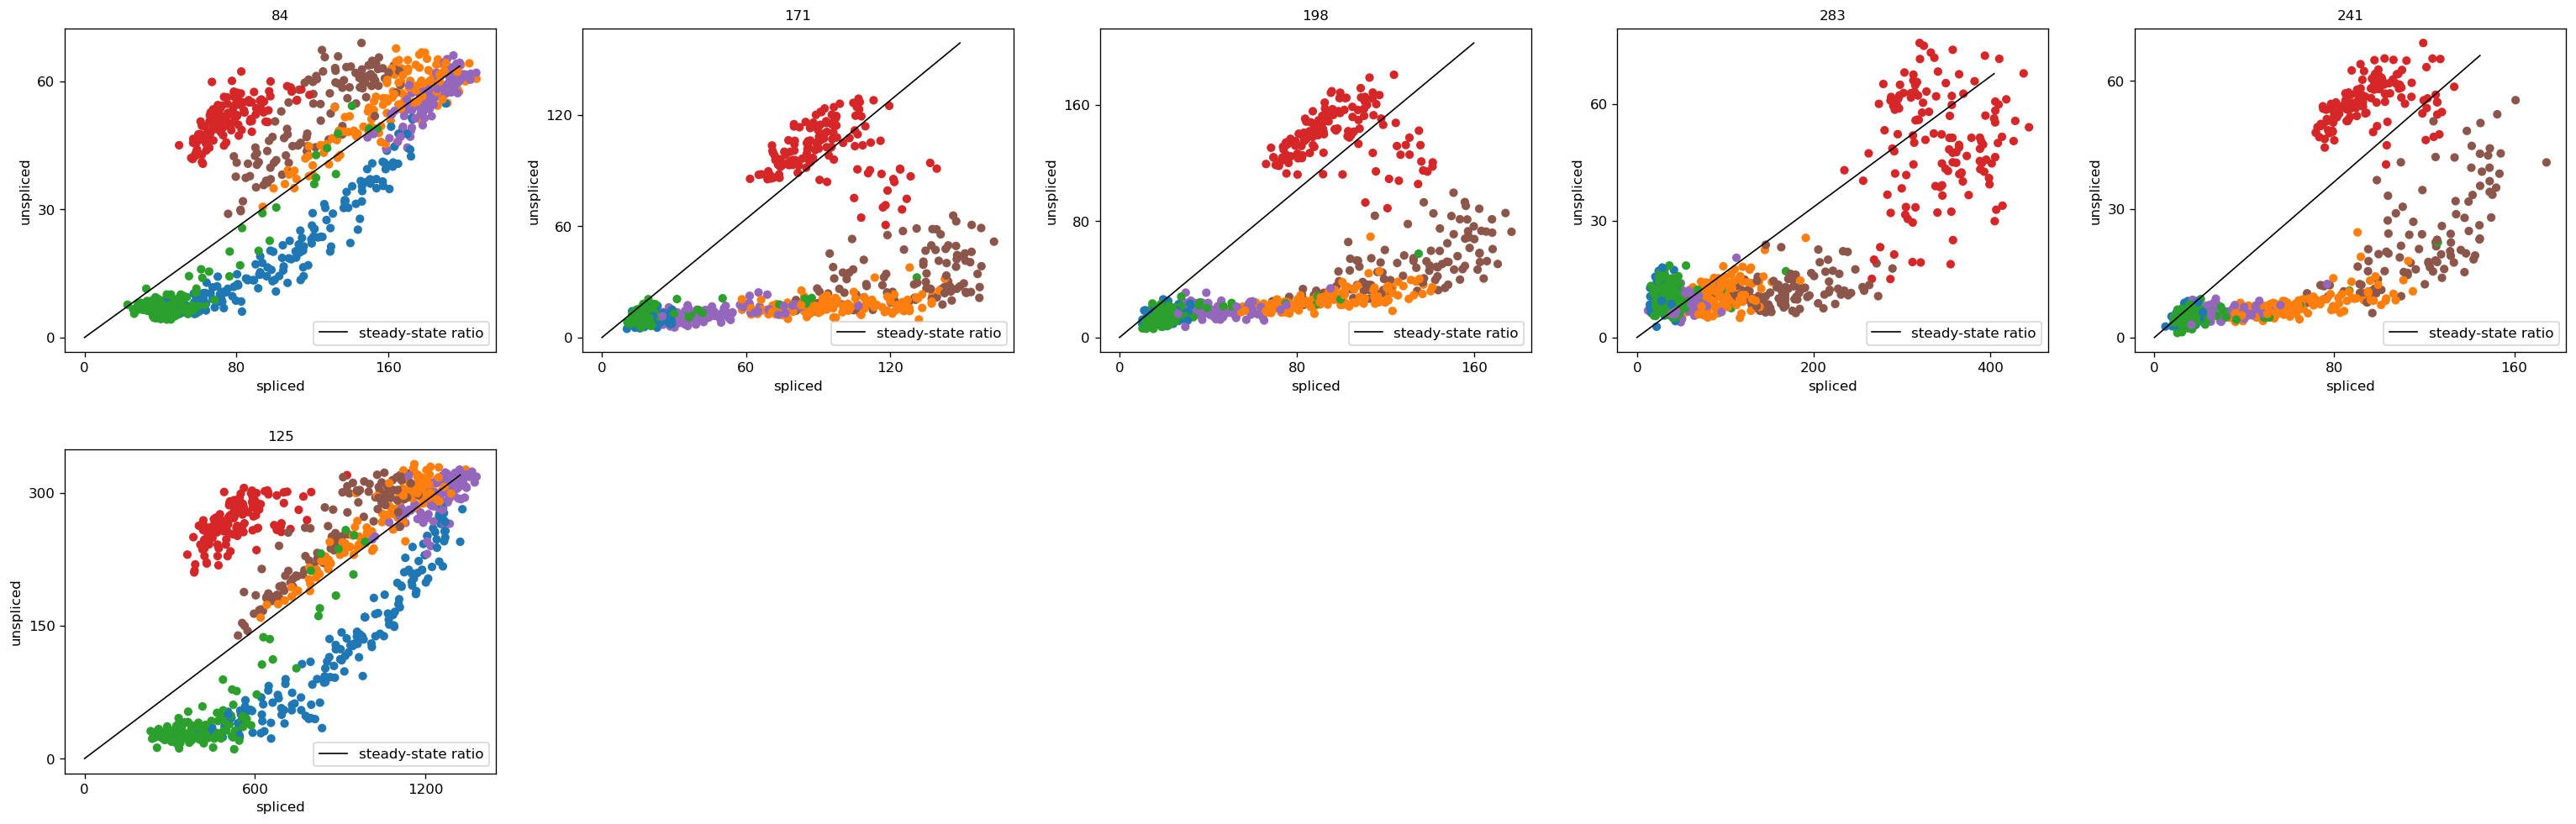

In [41]:
scv.pl.scatter(adata_s_u_800obs,color="leiden", basis=['84','171','198','283','241','125'], ncols=5, frameon=True,dpi=120,)

In [45]:
alpha = adata_n_c_800obs.var['true_alpha']
beta = adata_n_c_800obs.var['true_beta']
nu = adata_n_c_800obs.var['true_nu']
gamma = adata_n_c_800obs.var['true_gamma']

In [46]:
true_steady= ((gamma*(beta+nu))/(beta*nu))

In [101]:
diff = true_steady - adata_n_c_800obs.var['velocity_gamma']

In [49]:
true_steady[12]

2.4735153743290295

In [108]:
adata_n_c_800obs.var['velocity_gamma'][16]

10.555196

In [106]:
diff.argmin()

16

In [48]:
adata_n_c_800obs.var['velocity_gamma'][16]

10.555196

In [37]:
adata_n_c_800obs

AnnData object with n_obs × n_vars = 800 × 300
    obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'spliced', 'spliced_nuc', 'unspliced', 'velocity'
    obsp: 'connectivities', 'distances'

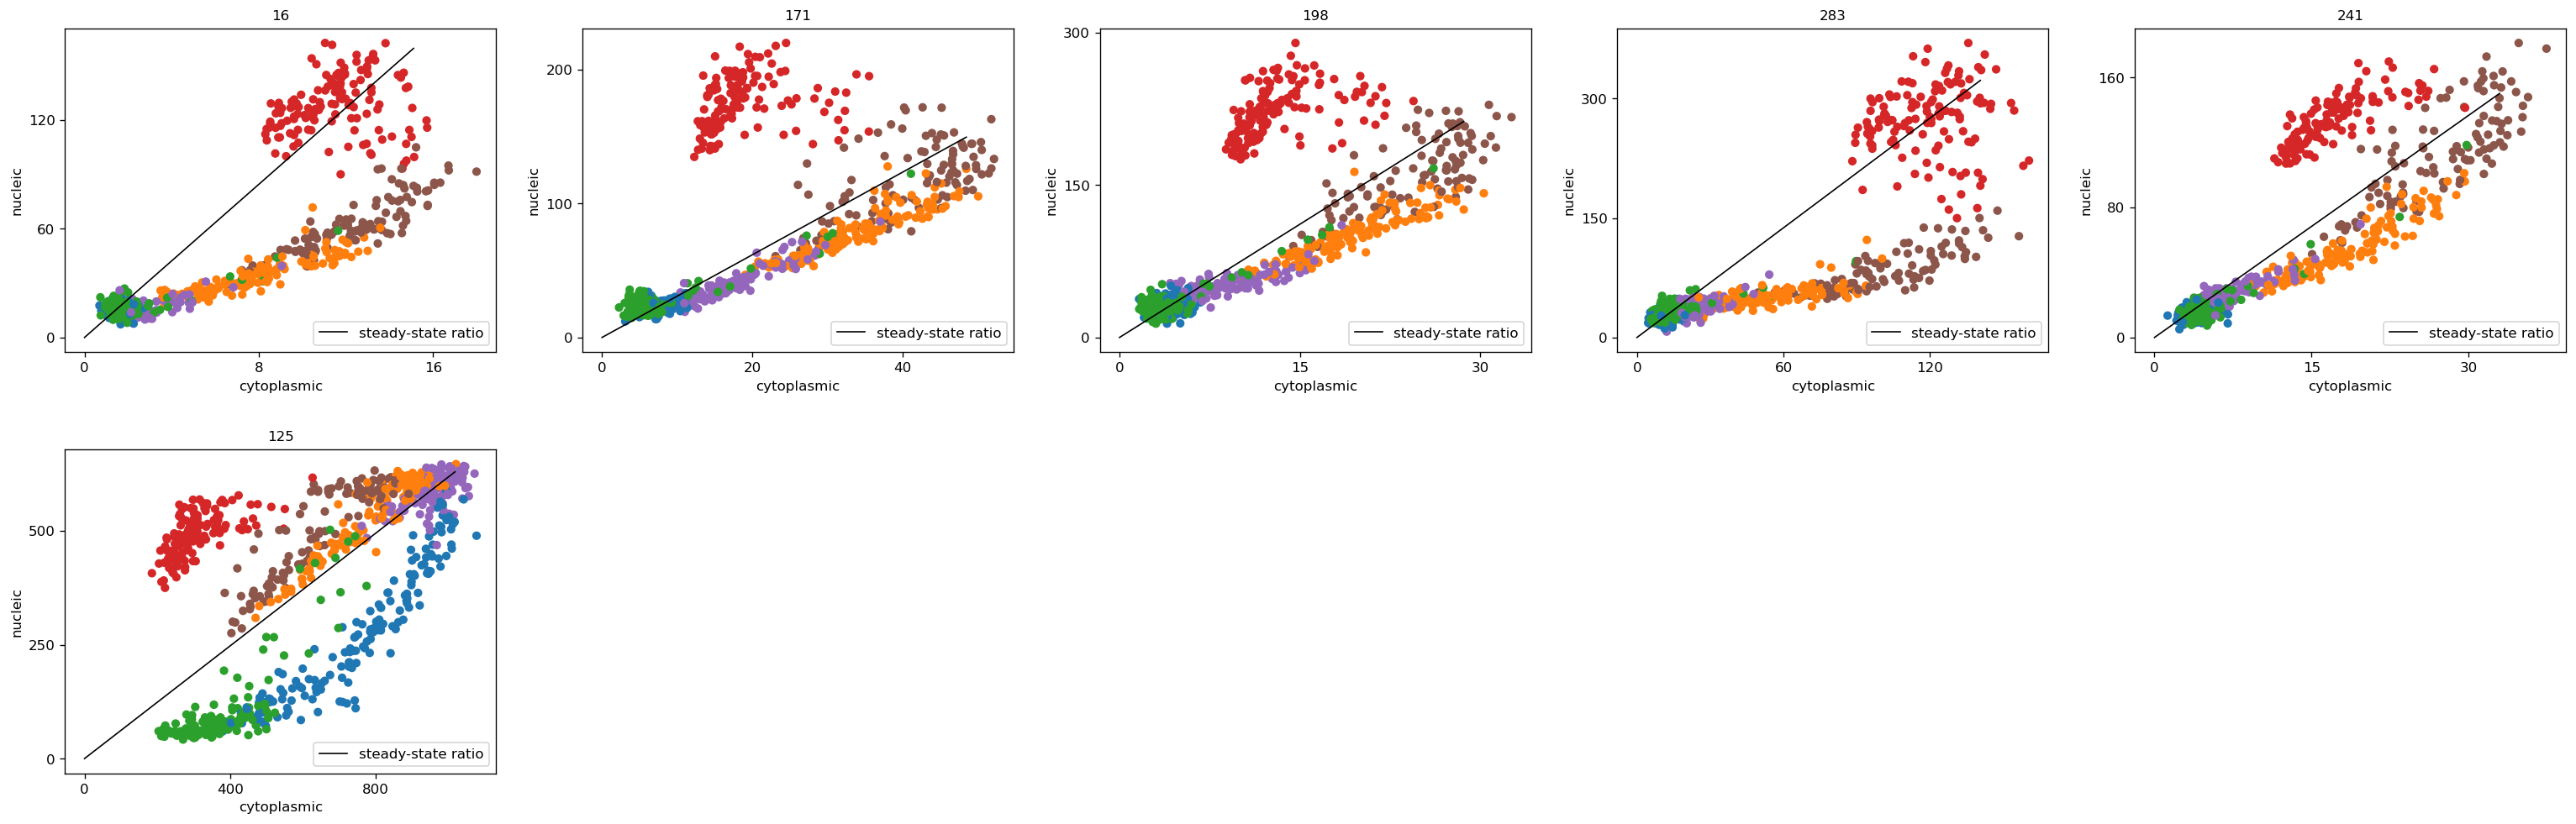

In [42]:
scv.pl.scatter(adata_n_c_800obs,color="leiden", basis=['16','171','198','283','241','125'], ncols=5, frameon=True,dpi=120, xlabel='cytoplasmic', ylabel='nucleic', vkey='velocity')

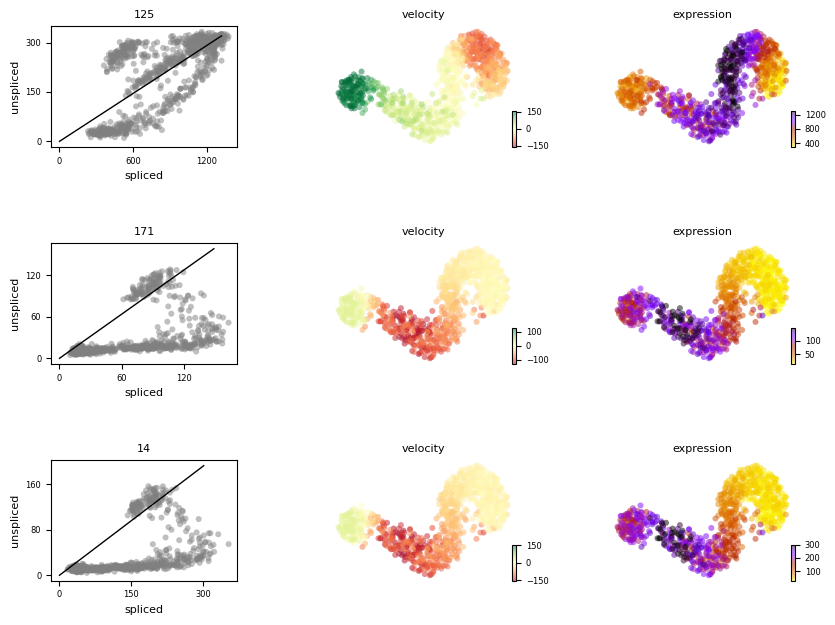

In [77]:
scv.pl.velocity(adata_s_u_800obs, ['125','171','14'])

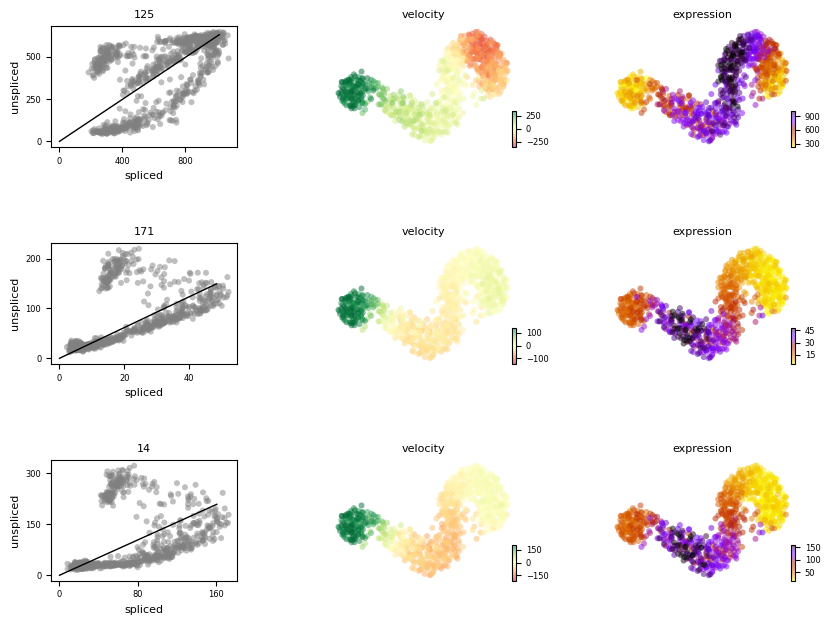

In [76]:
scv.pl.velocity(adata_n_c_800obs, ['125','171','14'])


In [74]:
adata_s_u_800obs.var.iloc[264,]

true_t_                11.044318
true_alpha             46.350653
true_beta               3.933081
true_nu                 0.561133
true_gamma              7.689878
true_scaling                 1.0
n_cells                      772
velocity_gamma          0.134229
velocity_qreg_ratio     0.134229
velocity_r2             0.238813
velocity_genes              True
Name: 264, dtype: object

In [73]:
adata_n_c_800obs.var.iloc[264,]

true_t_                11.044318
true_alpha             46.350653
true_beta               3.933081
true_nu                 0.561133
true_gamma              7.689878
true_scaling                 1.0
n_cells                      772
velocity_gamma         16.396784
velocity_qreg_ratio    16.396784
velocity_r2             0.890753
velocity_genes              True
Name: 264, dtype: object

In [81]:
(np.sum(adata_n_c_800obs.layers['unspliced'], axis=0) / np.sum(adata_n_c_800obs.layers['spliced'], axis=0)).mean()

3.2687246018260394

In [82]:
(np.sum(adata_s_u_800obs.layers['unspliced'], axis=0) / np.sum(adata_s_u_800obs.layers['spliced'], axis=0)).mean()

0.6086647123746314

In [45]:
a = np.sum(adata_n_c_800obs.layers['unspliced'], axis=1)/ np.sum(adata_n_c_800obs.layers['spliced'], axis=1)

In [66]:
adata_n_c_800obs.layers['unspliced'][2,14]

104.22667648337752

In [68]:
a = (adata_n_c_800obs.layers['unspliced'][:,14] / adata_n_c_800obs.layers['spliced'][:,14])

In [76]:
a[np.where((a<0.6) & (a>0.5))]

array([0.518961  , 0.59700683, 0.51089465, 0.51172895, 0.51427266,
       0.52835799, 0.58939215, 0.50021662, 0.53049618, 0.59855819,
       0.5221572 , 0.55384854, 0.56413662, 0.53966612, 0.59612905,
       0.59540625, 0.5773734 , 0.57397653, 0.58267469, 0.54167675,
       0.56630835, 0.52262431, 0.59102242, 0.58200027])

In [35]:
(np.sum(adata_n_c_800obs.layers['unspliced'], axis=1) / np.sum(adata_n_c_800obs.layers['spliced'], axis=1))[14]

(800,)

In [98]:
(np.sum(adata_s_u_800obs.layers['unspliced'], axis=0) / np.sum(adata_s_u_800obs.layers['spliced'], axis=0))[171]

0.5228704609354256

In [88]:
print (np.sum(adata_n_c_800obs.layers['velocity'],axis=0)[24], np.sum(adata_s_u_800obs.layers['velocity'],axis=0)[24]) 

-18393.932 -10786.287


In [66]:
(np.sum(adata_n_c_800obs.to_df('unspliced'),axis=0)/np.sum(adata_n_c_800obs.to_df('spliced'),axis=0))[14]

1.4804367829506135

In [77]:
# shuffle the gene counts for s and u, create new expression metrics to put in X.   
adata_n_c_800obs.layers['spliced'].shape

(800, 300)

# Velocity correlation by cell 

In [90]:
velocity_correlation_by_cell=velocity_corr_against_reference(adata_800,reference='adata_s_u_800obs_300genes_deterministic', mode= 'by_cell')

Text(0.5, 0, 'Correlation against reference')

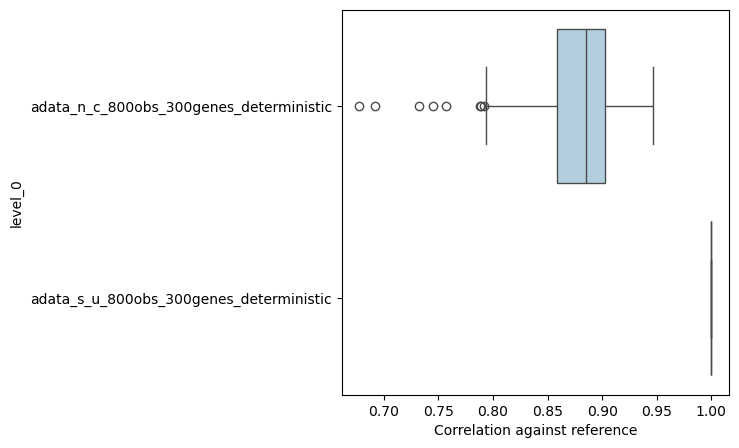

In [91]:
# same, but by cell
import matplotlib.pyplot as plt
# sns.clustermap(velocity_correlation_by_cell.fillna(0),figsize=(7,4),cmap='Blues')
plt.figure(figsize=(5,5))
sns.boxplot(data=velocity_correlation_by_cell.stack().reset_index(),y='level_0',x=0,palette='Blues')
plt.xlabel('Correlation against reference')

In [92]:
adata_800['adata_n_c_800obs_300genes_deterministic']

AnnData object with n_obs × n_vars = 800 × 300
    obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition', 'velocity_length', 'velocity_confidence', 'velocity_confidence_transition', 'Velocity confidence'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'spliced', 'spliced_nuc', 'unspliced', 'velocity'
    obsp: 'connectivities', 'distances'

In [93]:
leiden_s_u = adata_800['adata_s_u_800obs_300genes_deterministic'].obs['leiden']
velocity_conf_n_c = adata_800['adata_n_c_800obs_300genes_deterministic'].obs['velocity_confidence']
velocity_conf_s_u = adata_800['adata_s_u_800obs_300genes_deterministic'].obs['velocity_confidence']

In [94]:
velo_corr_cell = pd.DataFrame(velocity_correlation_by_cell.T)
velo_corr_cell['leiden'] = leiden_s_u 
velo_corr_cell['velocity_conf_n_c'] = velocity_conf_n_c
velo_corr_cell['velocitty_conf_s_u'] = velocity_conf_s_u


In [95]:
velo_corr_cell.sort_values('adata_n_c_800obs_300genes_deterministic')

,adata_n_c_800obs_300genes_deterministic,adata_s_u_800obs_300genes_deterministic,leiden,velocity_conf_n_c,velocitty_conf_s_u
688,0.677559,1.0,2,0.314761,0.417826
670,0.692411,1.0,2,0.445300,0.510577
658,0.731988,1.0,2,0.484108,0.511579
696,0.745078,1.0,2,0.398594,0.448728
680,0.757308,1.0,2,0.314163,0.372698
...,...,...,...,...,...
442,0.938527,1.0,0,0.782469,0.800602
525,0.940155,1.0,0,0.862729,0.877508
505,0.944134,1.0,0,0.835347,0.865429
444,0.945281,1.0,0,0.674302,0.720917


<Axes: xlabel='None', ylabel='adata_n_c_800obs_300genes_deterministic'>

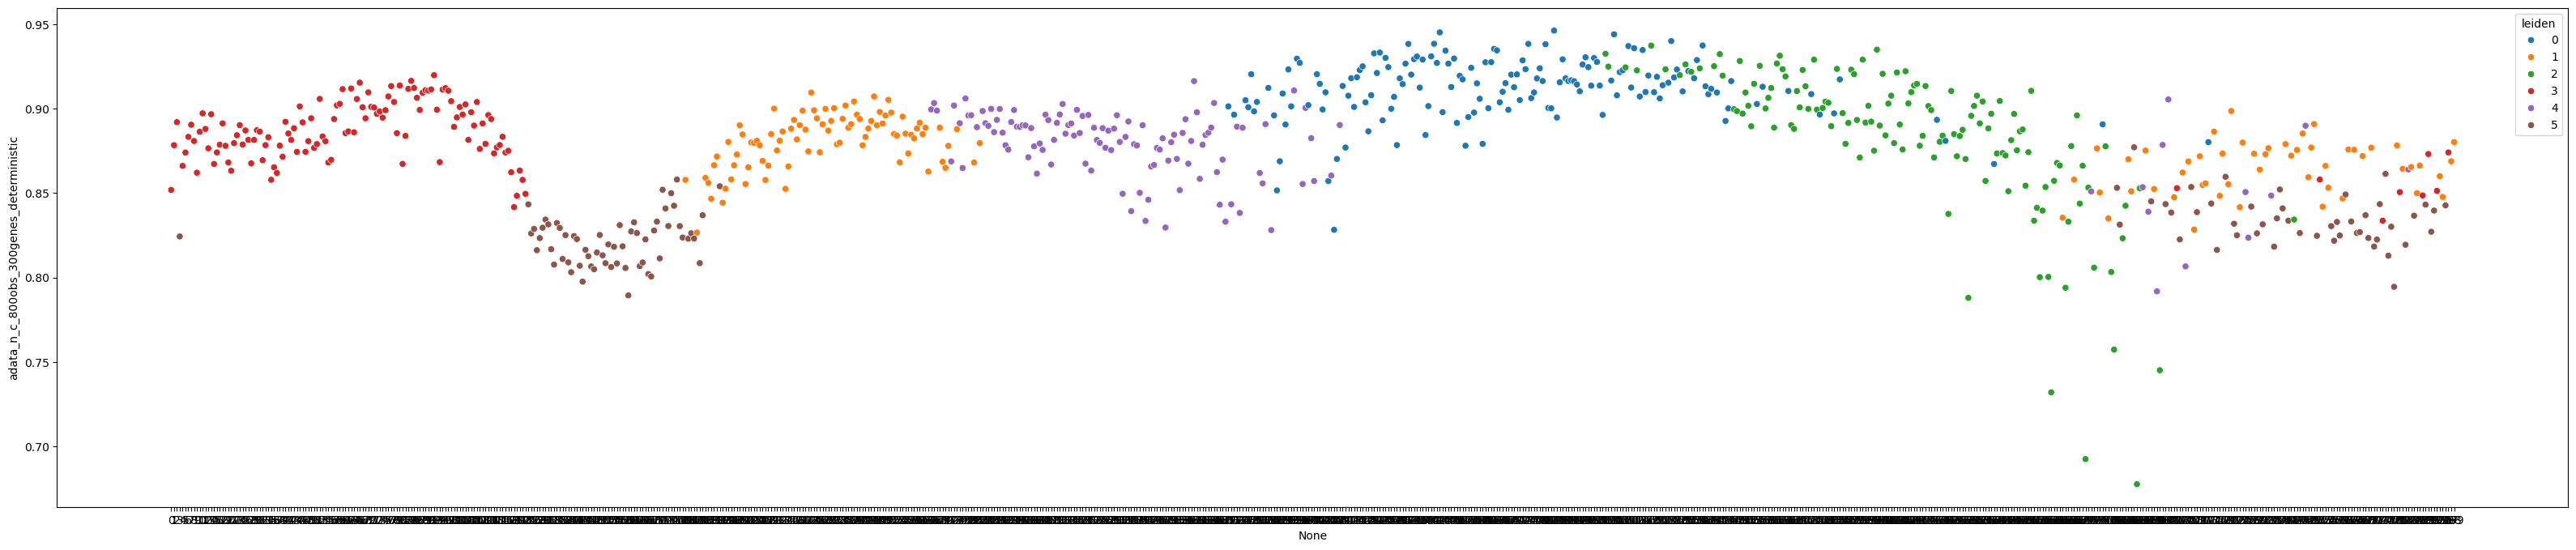

In [96]:
plt.figure(figsize=(40,8))
sns.scatterplot(data = velo_corr_cell, x = velo_corr_cell.index, y = 'adata_n_c_800obs_300genes_deterministic' , hue='leiden' )

- extreme velo differences between modalities happen mostly in leiden cluster 0. 

<Axes: xlabel='None', ylabel='velocitty_conf_s_u'>

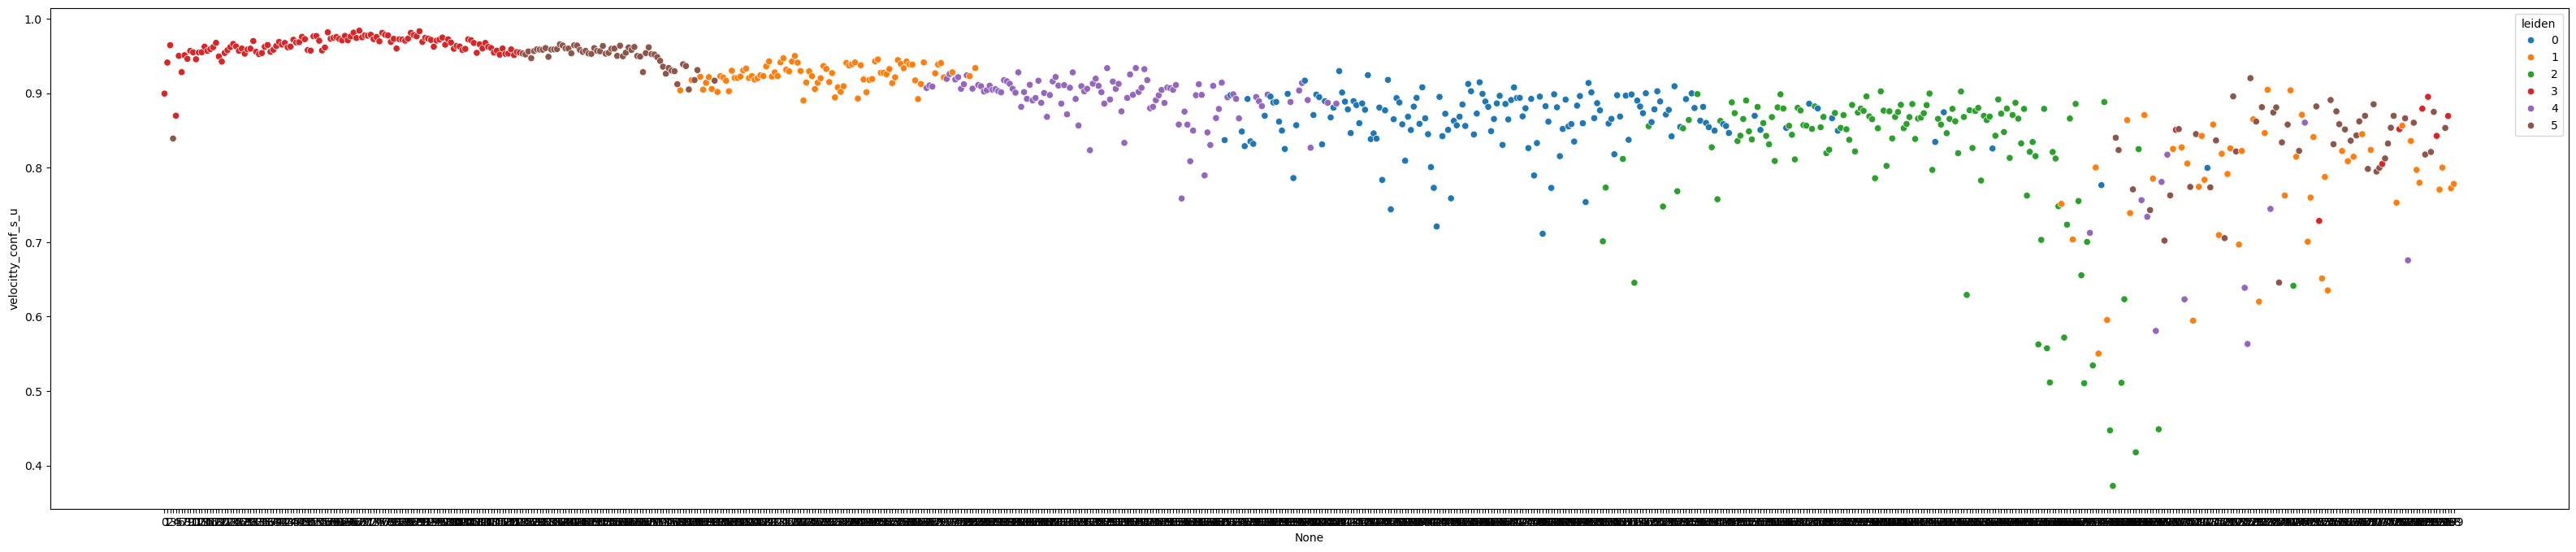

In [97]:
plt.figure(figsize=(40,8))
sns.scatterplot(data = velo_corr_cell, x = velo_corr_cell.index, y = 'velocitty_conf_s_u' , hue='leiden' )

<Axes: xlabel='None', ylabel='velocity_conf_n_c'>

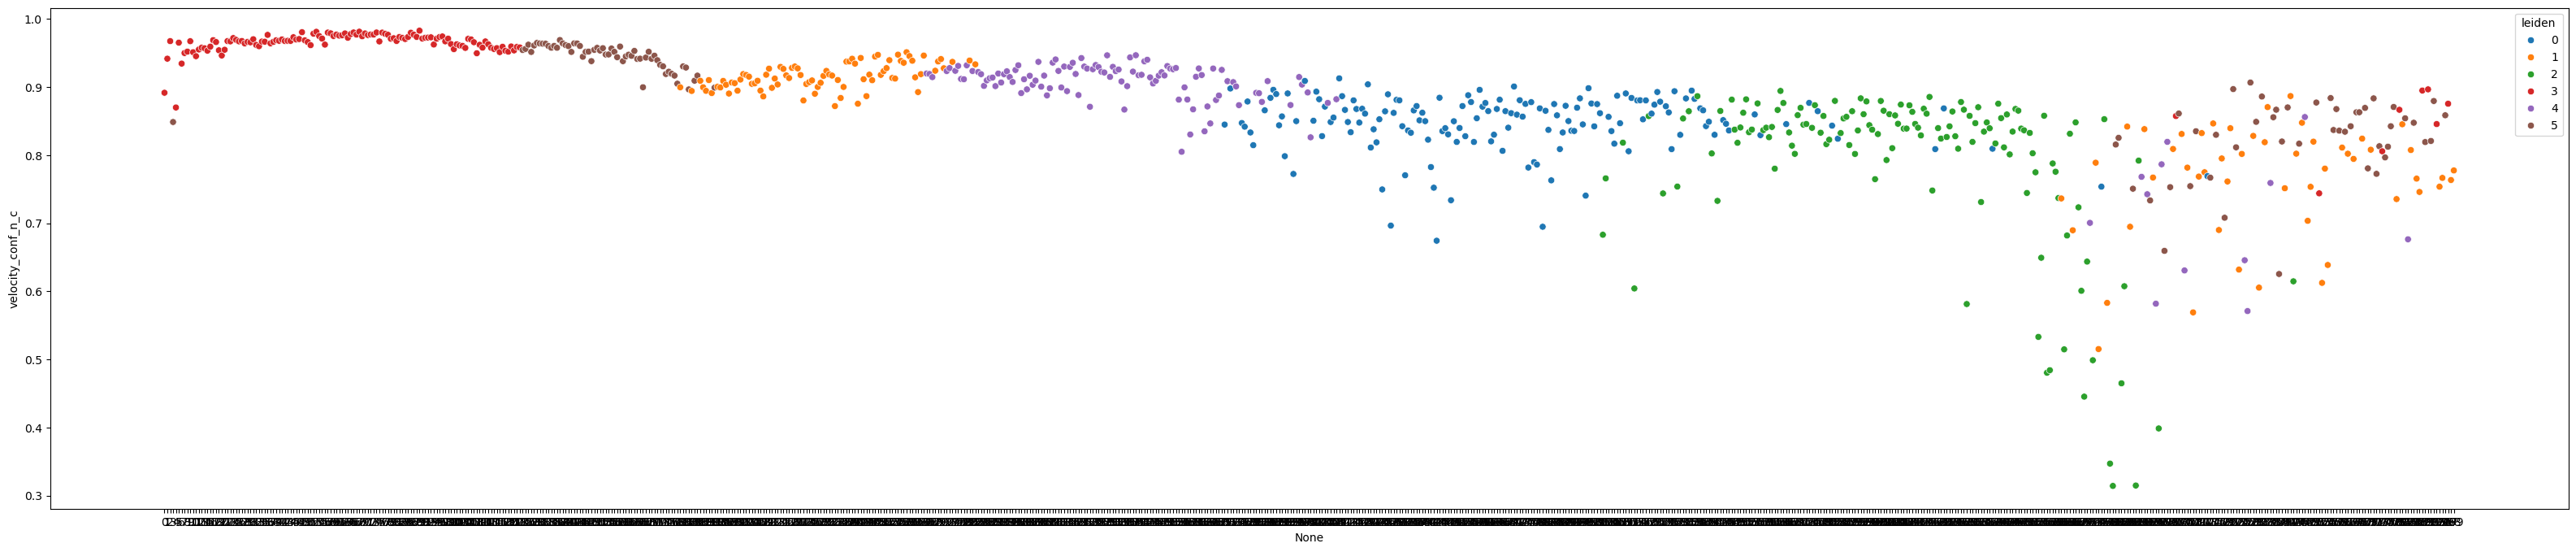

In [98]:
plt.figure(figsize=(40,8))
sns.scatterplot(data = velo_corr_cell, x = velo_corr_cell.index, y = 'velocity_conf_n_c' , hue='leiden' )

In [99]:
scv.tl.velocity_confidence(adata_800['adata_n_c_800obs_300genes_deterministic'])

--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)


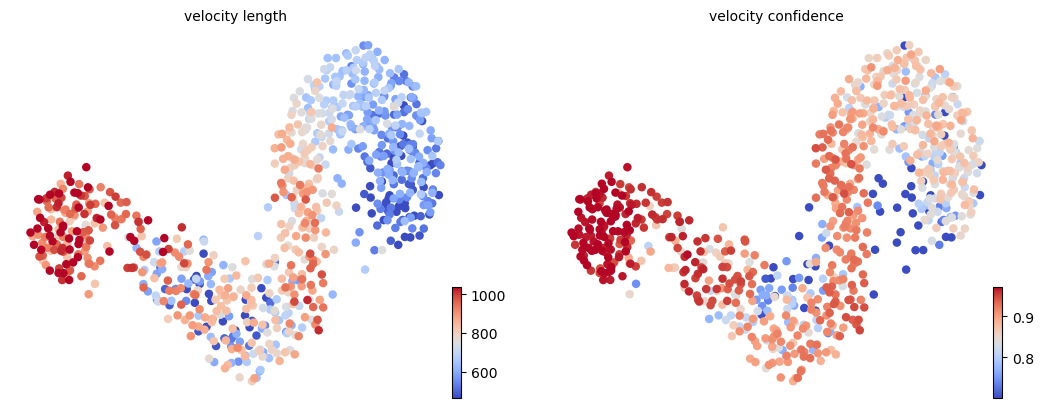

In [100]:
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata_800['adata_n_c_800obs_300genes_deterministic'], c=keys, cmap='coolwarm', perc=[5, 95])

--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)


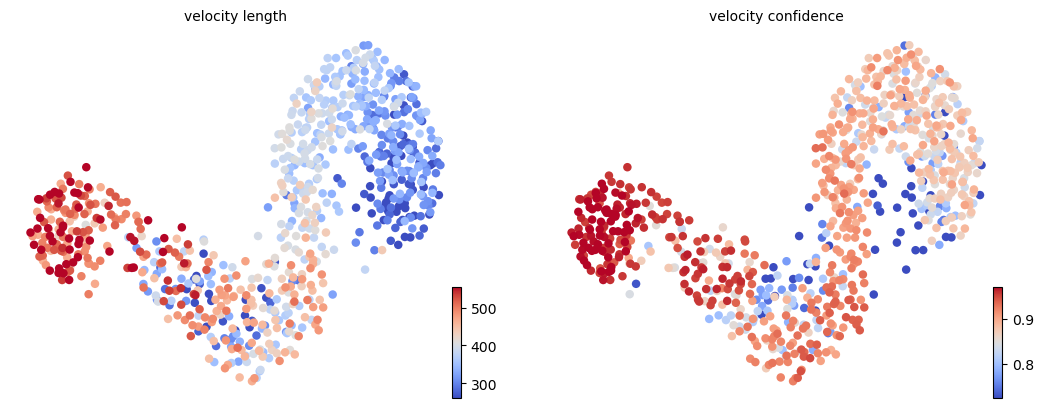

In [101]:
scv.tl.velocity_confidence(adata_800['adata_s_u_800obs_300genes_deterministic'])
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata_800['adata_s_u_800obs_300genes_deterministic'], c=keys, cmap='coolwarm', perc=[5, 95])

- Both of the modalities has the lowest values for velocity confidence for the cells differs in correlation the most. They can be filtered.

### Check the low correlated cells 

- check the times 

In [102]:
velo_corr_cell.sort_values('adata_n_c_800obs_300genes_deterministic').iloc[654]

adata_n_c_800obs_300genes_deterministic     0.91057
adata_s_u_800obs_300genes_deterministic         1.0
leiden                                            0
velocity_conf_n_c                           0.84555
velocitty_conf_s_u                         0.853338
Name: 566, dtype: object

In [103]:
b = (np.sum(adata_s_u_800obs.layers['unspliced'], axis=1) / np.sum(adata_s_u_800obs.layers['spliced'], axis=1))

In [104]:
np.argmin(b)

718

In [126]:
(np.sum(adata_n_c_800obs.layers['unspliced'], axis=1) / np.sum(adata_n_c_800obs.layers['spliced'], axis=1))

0.7827896542018831

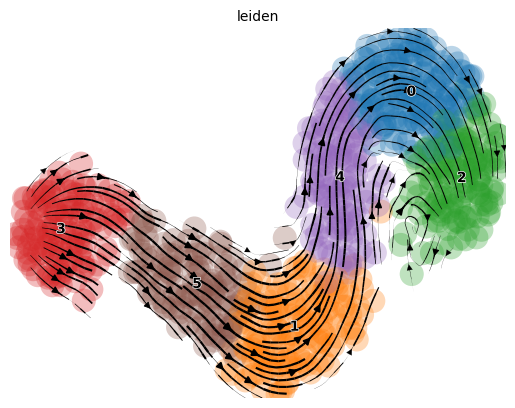

In [105]:
scv.pl.velocity_embedding_stream(adata_s_u_800obs, basis='umap', color='leiden')

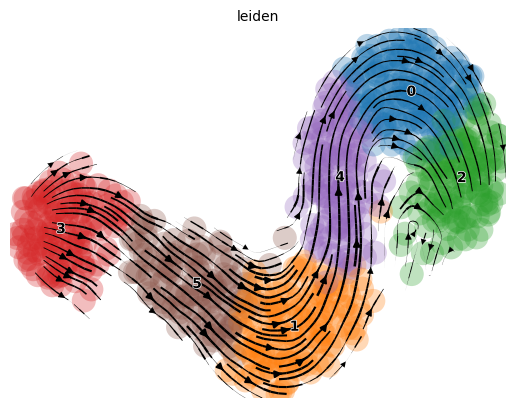

In [106]:
scv.pl.velocity_embedding_stream(adata_n_c_800obs, basis='umap', color='leiden')

# Check the important genes 

In [107]:
scv.tl.rank_velocity_genes(adata_s_u_800obs, groupby='leiden', min_corr=.3)
scv.tl.rank_velocity_genes(adata_n_c_800obs, groupby='leiden', min_corr=.3)

ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
ranking velocity genes
    finished (0:00:00) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)


In [108]:
dfs = scv.get_df(adata_s_u_800obs.uns['rank_velocity_genes']['names'])
dfs.head(5)

,0,1,2,3,4,5
0,283,105,283,25,99,101
1,16,195,16,13,166,199
2,173,208,204,193,268,195
3,159,37,173,17,214,105
4,204,117,296,61,24,90


In [109]:
dfn = scv.get_df(adata_n_c_800obs.uns['rank_velocity_genes']['names'])
dfn.head(5)

,0,1,2,3,4,5
0,16,208,34,171,166,90
1,283,195,97,67,99,186
2,204,168,283,198,126,88
3,99,38,204,241,34,195
4,126,186,16,25,75,202


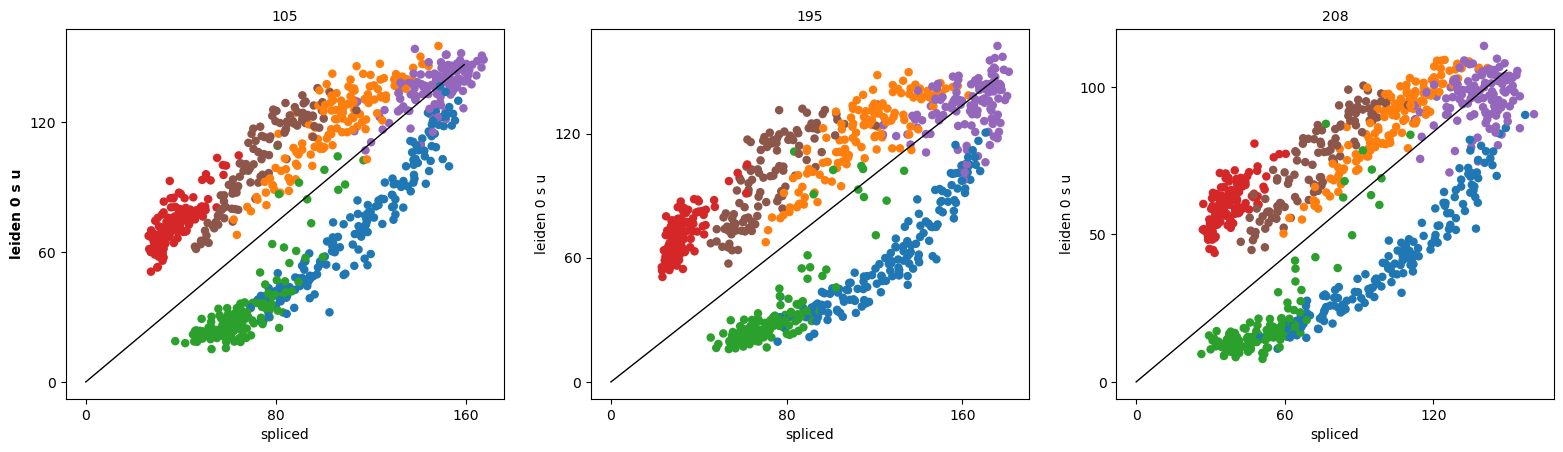

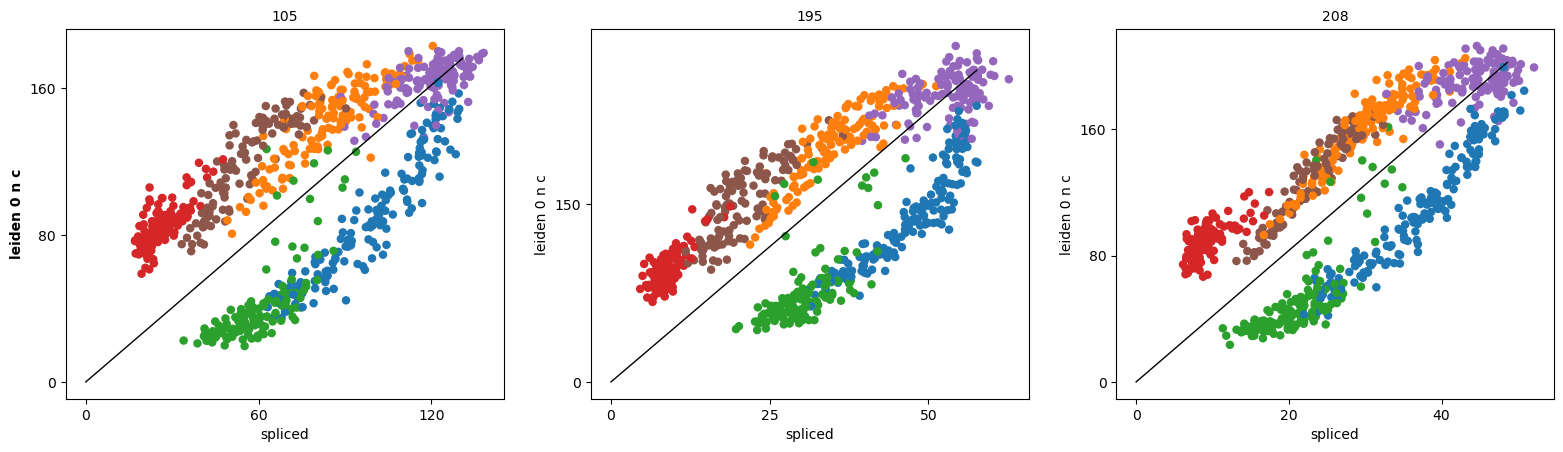

In [110]:
scv.pl.scatter(adata_s_u_800obs, dfs['1'][:3], ylabel='leiden 0 s_u', color='leiden')
scv.pl.scatter(adata_n_c_800obs, dfs['1'][:3], ylabel='leiden 0 n_c', color= 'leiden')

In [51]:
adata_n_c_800obs

AnnData object with n_obs × n_vars = 800 × 300
    obs: 'true_t', 'n_counts', 'leiden', 'velocity_self_transition'
    var: 'true_t_', 'true_alpha', 'true_beta', 'true_nu', 'true_gamma', 'true_scaling', 'n_cells', 'velocity_gamma', 'velocity_qreg_ratio', 'velocity_r2', 'velocity_genes', 'spearmans_score', 'velocity_score'
    uns: 'leiden', 'log1p', 'neighbors', 'pca', 'umap', 'velocity_graph', 'velocity_graph_neg', 'velocity_params', 'leiden_colors', 'rank_velocity_genes'
    obsm: 'X_pca', 'X_umap', 'velocity_umap'
    varm: 'PCs'
    layers: 'Ms', 'Mu', 'spliced', 'unspliced', 'velocity'
    obsp: 'connectivities', 'distances'

# Velocity Confidence

--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


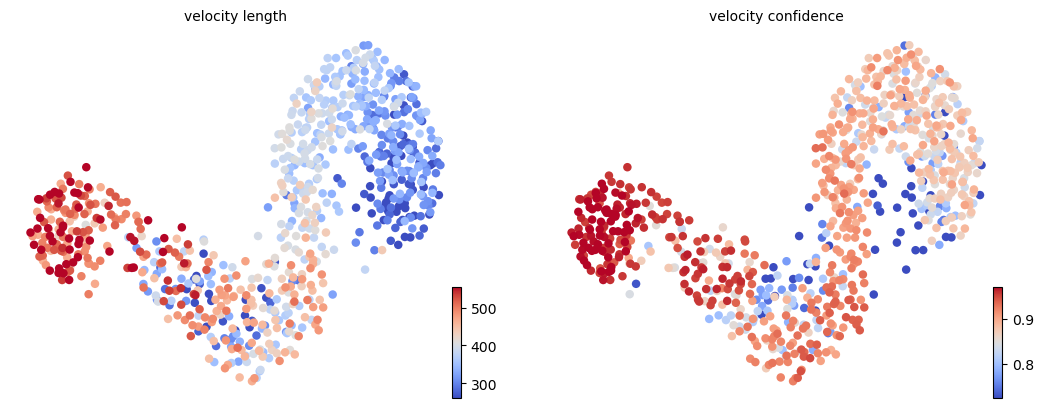

In [111]:
scv.tl.velocity_confidence(adata_s_u_800obs)
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata_s_u_800obs, c=keys, cmap='coolwarm', perc=[5, 95])

--> added 'velocity_length' (adata.obs)
--> added 'velocity_confidence' (adata.obs)
--> added 'velocity_confidence_transition' (adata.obs)


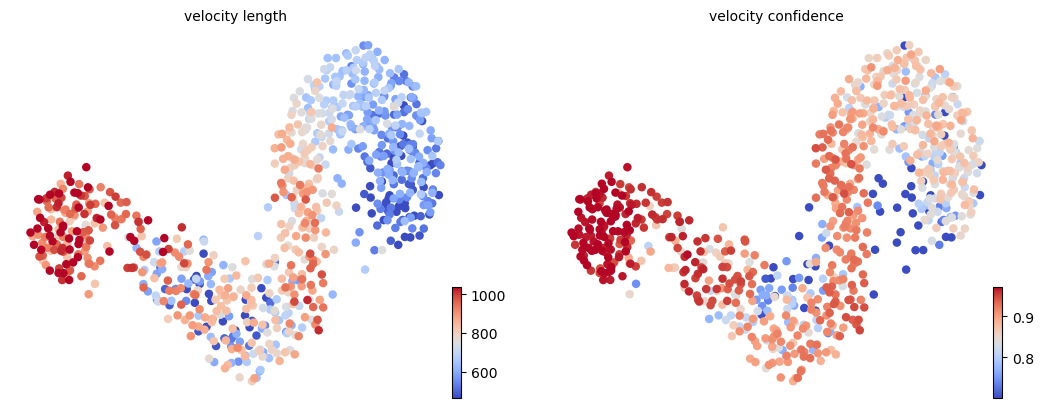

In [112]:
scv.tl.velocity_confidence(adata_n_c_800obs)
keys = 'velocity_length', 'velocity_confidence'
scv.pl.scatter(adata_n_c_800obs, c=keys, cmap='coolwarm', perc=[5, 95])

In [113]:
keys = ['velocity_length', 'velocity_confidence']
df = adata_s_u_800obs.obs.groupby('leiden')[keys].mean().T
df.style.background_gradient(cmap='coolwarm', axis=1)

leiden,0,1,2,3,4,5
velocity_length,344.796265,406.687012,292.785217,518.073669,390.104675,428.994598
velocity_confidence,0.863637,0.871466,0.811065,0.955931,0.876532,0.897651


In [114]:
keys = ['velocity_length', 'velocity_confidence']
df = adata_n_c_800obs.obs.groupby('leiden')[keys].mean().T
df.style.background_gradient(cmap='coolwarm', axis=1)

leiden,0,1,2,3,4,5
velocity_length,628.929749,747.023499,534.510864,970.659973,808.890930,770.087097
velocity_confidence,0.847350,0.859130,0.789076,0.958360,0.889832,0.891938


# Sign Accuracy 

In [116]:
adata_800['random'] = adata_random

In [117]:
scv.pp.moments(adata_800['random'], n_pcs=None, n_neighbors=None)
scv.tl.velocity_graph(adata_800['random'])

computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocity graph (using 1/24 cores)
    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


In [118]:
sign_accuracies=get_sign_accuracy(adata_800)

adata_n_c_800obs_300genes_deterministic


100%|██████████| 656/656 [00:00<00:00, 13374.99it/s]


adata_s_u_800obs_300genes_deterministic


100%|██████████| 656/656 [00:00<00:00, 20866.71it/s]


random


100%|██████████| 656/656 [00:00<00:00, 17304.15it/s]


<Axes: xlabel='Accuracy', ylabel='Model'>

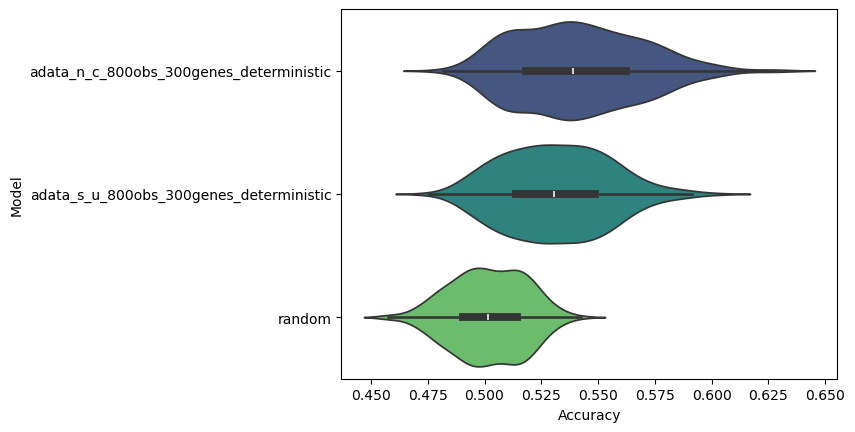

In [119]:
sns.violinplot(data=sign_accuracies,y='Model',x='Accuracy',palette='viridis')